[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/evinracher/3008338-geospatial-analysis/blob/main/project/house-price-medellin.ipynb)

# Introduccción

En este notebook se presenta el desarrollo de un proyecto para predecir el precio de las viviendas en Medellín mediante diferentes modelos de aprendizaje de máquinas. Se presenta una comparación de diferentes modelos, entrenados en un dataset disponible en Kaggle, que recopila la información de varias viviendas en Colombia. Incluye información como número de habitaciones, número de baños, área total del inmueble y precio.

Para realizar este proyecto, se filtró la información solo de los inmuebles ubicados en Medellín y se hizo el procesamiento de datos adecuado para filtrar registros con información faltante o datos errados.


Dataset principal: https://www.kaggle.com/datasets/julianusugaortiz/colombia-housing-properties-price

In [1]:
%matplotlib inline
# needed in jupyter notebook
import matplotlib.pyplot as plt

# Carga de datos

Se cargan los datos desde Kaggle directamente, usando la API de Kaggle

In [2]:
# Instalando las dependencias necesarias
%pip install kagglehub scikit-learn


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
# Requires libomp: On Mac, you can install it running: brew install libomp
%pip install xgboost


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
from pathlib import Path

import kagglehub
import pandas as pd

# Download latest version
dataset_path = Path(
    kagglehub.dataset_download("julianusugaortiz/colombia-housing-properties-price")
)

print("Path to dataset files:", dataset_path)

# Find and load the CSV file
csv_files = list(dataset_path.glob("*.csv"))
print("CSV files:", [file.name for file in csv_files])

csv_path = dataset_path / "co_properties.csv"
df = pd.read_csv(csv_path)

df.head()

/opt/anaconda3/envs/ml_tf/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /Users/kevin.parra/.cache/kagglehub/datasets/julianusugaortiz/colombia-housing-properties-price/versions/2
CSV files: ['co_properties.csv']


,id,ad_type,start_date,end_date,created_on,lat,lon,l1,l2,l3,...,bathrooms,surface_total,surface_covered,price,currency,price_period,title,description,property_type,operation_type
0,KsjahK62rxcYKXXQjOdkqw==,Propiedad,2020-10-07,2021-10-09,2020-10-07,3.9210,-76.506000,Colombia,Valle del Cauca,NaN,...,7.0,NaN,NaN,1.300000e+09,COP,NaN,Casa Campestre en venta en darien 3469064,"HERMOSA CASA CAMPESTRE, &Aacute;REA 6,000 MT, ...",Casa,Venta
1,Y+gsBZYq1zu5NoR3V5oUGA==,Propiedad,2020-10-07,2021-01-06,2020-10-07,3.3577,-76.541811,Colombia,Valle del Cauca,Cali,...,7.0,NaN,NaN,2.800000e+09,COP,NaN,Casa en ciudsd jardin,Casa independiente con posiciona en ciudad jar...,Casa,Venta
2,Jpzqxj8/Vgf3Aa5ASxUBNg==,Propiedad,2020-10-07,2020-10-07,2020-10-07,3.3577,-76.541811,Colombia,Valle del Cauca,Cali,...,7.0,NaN,NaN,2.800000e+09,COP,Mensual,Casa en ciudsd jardin,Casa independiente con posiciona en ciudad jar...,Casa,Venta
3,ieuFnkFx/yHDD66iMV14Gw==,Propiedad,2020-10-07,2021-04-12,2020-10-07,3.3640,-76.538000,Colombia,Valle del Cauca,Cali,...,8.0,NaN,NaN,3.500000e+09,COP,NaN,Casa en venta en pance 1630426,"EXCELENTE CASA - LOTE 6,373 MT, EN OBRA GRIS U...",Casa,Venta
4,g4u5JM+hAHEk8SukRSjMzg==,Propiedad,2020-10-07,9999-12-31,2020-10-07,3.3910,-76.517000,Colombia,Valle del Cauca,Cali,...,9.0,NaN,NaN,4.800000e+08,COP,NaN,CASA EXTERNA BARRIO CIUDAD 2000,"CASA EXTERNA EN EL BARRIO CIUDAD 2000,CONSTRUI...",Casa,Venta


# Procesamiento y exploración de los datos

El dataset tiene varias características que no son importantes para el problema, como la columna l1, que representa el país donde está ubicado el inmueble y para la cual todos los registros tienen el valor de "Colombia". Así mismo, ad_type, que tiene el mismo valor para todos los registros y no aporta ningún valor a los modelos.

Por lo tanto, se van a eliminar esas columnas

In [5]:
columns_to_keep = [
    "lat",
    "lon",
    "l3",
    "l4",
    "l5",
    "l6",
    "rooms",
    "bedrooms",
    "bathrooms",
    "surface_total",
    "surface_covered",
    "price",
    "title",
    "property_type",
    "operation_type",
]

discarded_columns = [col for col in df.columns if col not in columns_to_keep]

df_selected = df[columns_to_keep].copy()

print("Discarded columns:")
print(discarded_columns)

df_selected.head()

Discarded columns:
['id', 'ad_type', 'start_date', 'end_date', 'created_on', 'l1', 'l2', 'currency', 'price_period', 'description']


,lat,lon,l3,l4,l5,l6,rooms,bedrooms,bathrooms,surface_total,surface_covered,price,title,property_type,operation_type
0,3.9210,-76.506000,NaN,NaN,NaN,NaN,NaN,6.0,7.0,NaN,NaN,1.300000e+09,Casa Campestre en venta en darien 3469064,Casa,Venta
1,3.3577,-76.541811,Cali,Ciudad Jardín,NaN,NaN,NaN,NaN,7.0,NaN,NaN,2.800000e+09,Casa en ciudsd jardin,Casa,Venta
2,3.3577,-76.541811,Cali,Ciudad Jardín,NaN,NaN,NaN,NaN,7.0,NaN,NaN,2.800000e+09,Casa en ciudsd jardin,Casa,Venta
3,3.3640,-76.538000,Cali,Ciudad Jardín,NaN,NaN,NaN,5.0,8.0,NaN,NaN,3.500000e+09,Casa en venta en pance 1630426,Casa,Venta
4,3.3910,-76.517000,Cali,NaN,NaN,NaN,NaN,8.0,9.0,NaN,NaN,4.800000e+08,CASA EXTERNA BARRIO CIUDAD 2000,Casa,Venta


A continuación se presenta el significado de algunas columnas:

l1: País

l2: Departamento

l3: Cuidad

l4: Zona

l5: Localidad

l6: Barrio (Neighborhood)

Vamos a explorar los valores de estas columnas y ver si nos pueden aportar algo o por el contrario las podemos eliminar, recordando que se utilizarán solo los datos de inmuebles en Medellín

In [6]:
for col in ["l3", "l4", "l5", "l6"]:
    print(f"\nUnique values in {col}:")
    print(df_selected[col].dropna().unique())
    print(f"Total unique values: {df_selected[col].nunique(dropna=True)}")


Unique values in l3:
<StringArray>
[                'Cali',                 'Chía',                'Dagua',
              'Pereira',              'Jamundí',             'Restrepo',
            'Manizales',             'Medellín',           'Bogotá D.C',
          'Santa Marta',
 ...
              'Quipile', 'El Carmen de Bolívar',              'Caqueza',
           'Caicedonia',              'Fúquene',              'Buesaco',
              'Yaguará',          'Nuevo Colón',               'Sotara',
                'Ataco']
Length: 343, dtype: str
Total unique values: 343

Unique values in l4:
<StringArray>
[         'Ciudad Jardín',     'San Fernando Nuevo',               'Laureles',
     'Zona Noroccidental',        'Zona Occidental',         'Zona Chapinero',
                  'Caney',                   'Lili',        'Doce de Octubre',
             'La América',                  'Belén',             'El Poblado',
          'Villa Hermosa',             'Zona Norte',     'Zona Surocci

Sin duda estas columnas tienen bastantes valores únicos, representando diferentes barrios y localidades.

## Filtrando los datos de solo Medellín

Sin embargo, nuestro interés es filtrar solo la información de Medellín, vamos a filtrar el dataset para obtener solo los datos que nos interesan.

In [7]:
df_medellin = df_selected[df_selected["l3"] == "Medellín"].copy()

print("Medellín dataset shape:", df_medellin.shape)

df_medellin.head()

Medellín dataset shape: (262856, 15)


,lat,lon,l3,l4,l5,l6,rooms,bedrooms,bathrooms,surface_total,surface_covered,price,title,property_type,operation_type
46,NaN,NaN,Medellín,NaN,NaN,NaN,NaN,NaN,8.0,NaN,NaN,4.000000e+09,Casa en Venta Ubicado en MEDELLIN,Casa,Venta
47,6.238637,-75.602011,Medellín,Laureles,NaN,NaN,NaN,19.0,20.0,NaN,NaN,1.300000e+07,"CASA EN ARRIENDO, MEDELLIN-LAURELES",Casa,Arriendo
48,NaN,NaN,Medellín,NaN,NaN,NaN,NaN,NaN,7.0,NaN,NaN,1.500000e+07,Casa en Arriendo Ubicado en MEDELLIN,Casa,Arriendo
157,6.297802,-75.577835,Medellín,Doce de Octubre,NaN,NaN,5.0,5.0,NaN,NaN,NaN,3.100000e+08,Venta de casa en Florencia,Casa,Venta
158,6.245972,-75.614730,Medellín,La América,NaN,NaN,7.0,7.0,NaN,NaN,NaN,2.500000e+06,Arriendo Casa Duplex en Santa Monica,Casa,Arriendo


In [8]:
for col in ["l4", "l5", "l6"]:
    print(f"\nUnique values in {col}:")
    print(df_medellin[col].unique())
    print(f"Total unique values: {df_medellin[col].nunique()}")


Unique values in l4:
<StringArray>
[                   nan,             'Laureles',      'Doce de Octubre',
           'La América',                'Belén',           'El Poblado',
        'Villa Hermosa',              'Robledo',             'Castilla',
           'San Javier',        'San Cristóbal',           'Santa Cruz',
          'Santa Elena',             'Guayabal',             'Aranjuez',
           'Candelaria',            'Altavista',             'Manrique',
         'Buenos Aires',              'Popular', 'San Antonio de Prado',
             'Palmitas']
Length: 22, dtype: str
Total unique values: 21

Unique values in l5:
<StringArray>
[nan]
Length: 1, dtype: str
Total unique values: 0

Unique values in l6:
<StringArray>
[nan]
Length: 1, dtype: str
Total unique values: 0


Vemos que para Medellín, las columnas l5 y l6 no tienen ningún valor representativo, por tanto vamos a eliminarlas.

In [9]:
df_medellin = df_medellin.drop(columns=["l5", "l6"])

print("Medellín dataset shape after dropping l5 and l6:", df_medellin.shape)
print("Remaining columns:")
print(df_medellin.columns.tolist())

df_medellin.head()

Medellín dataset shape after dropping l5 and l6: (262856, 13)
Remaining columns:
['lat', 'lon', 'l3', 'l4', 'rooms', 'bedrooms', 'bathrooms', 'surface_total', 'surface_covered', 'price', 'title', 'property_type', 'operation_type']


,lat,lon,l3,l4,rooms,bedrooms,bathrooms,surface_total,surface_covered,price,title,property_type,operation_type
46,NaN,NaN,Medellín,NaN,NaN,NaN,8.0,NaN,NaN,4.000000e+09,Casa en Venta Ubicado en MEDELLIN,Casa,Venta
47,6.238637,-75.602011,Medellín,Laureles,NaN,19.0,20.0,NaN,NaN,1.300000e+07,"CASA EN ARRIENDO, MEDELLIN-LAURELES",Casa,Arriendo
48,NaN,NaN,Medellín,NaN,NaN,NaN,7.0,NaN,NaN,1.500000e+07,Casa en Arriendo Ubicado en MEDELLIN,Casa,Arriendo
157,6.297802,-75.577835,Medellín,Doce de Octubre,5.0,5.0,NaN,NaN,NaN,3.100000e+08,Venta de casa en Florencia,Casa,Venta
158,6.245972,-75.614730,Medellín,La América,7.0,7.0,NaN,NaN,NaN,2.500000e+06,Arriendo Casa Duplex en Santa Monica,Casa,Arriendo


In [10]:
print("Operation types")
print(df_medellin["operation_type"].dropna().unique())

Operation types
<StringArray>
['Venta', 'Arriendo', 'Arriendo temporal']
Length: 3, dtype: str


In [11]:
# Cantidad de registros por tipo de operación
print("\nRecords by operation type")
print(df_medellin["operation_type"].value_counts(dropna=False))


Records by operation type
operation_type
Arriendo             143439
Venta                119394
Arriendo temporal        23
Name: count, dtype: int64


In [12]:
print(df_medellin["property_type"].unique())

<StringArray>
[           'Casa',            'Lote',            'Otro',         'Oficina',
     'Apartamento', 'Local comercial',           'Finca',        'Depósito',
     'Parqueadero']
Length: 9, dtype: str


Así mismo, vemos que hay dos tipos de operaciones en el dataset: Venta y arriendo. En este proyecto nos enfocaremos solo en el precio de venta de un inmueble. Por tanto, vamos a filtrar solo por este tipo de operación

In [13]:
df_medellin = df_medellin[df_medellin["operation_type"] == "Venta"].copy()

df_medellin.drop(columns=["operation_type"], inplace=True)

Eliminamos adicionalmente otras columnas cuyos valores se repiten (en este caso, l3 que representa la ciudad y para nuestro subconjunto es la misma, Medellín); así mismo eliminamos columnas que no aportan mucho valor a nuestro problema:

In [14]:
df_medellin_clean = df_medellin.drop(columns=["l3", "title"]).copy()

In [15]:
df_medellin_clean.describe()

,lat,lon,rooms,bedrooms,bathrooms,surface_total,surface_covered,price
count,36540.000000,36540.000000,11889.000000,20456.000000,102697.000000,1356.000000,1442.000000,1.193700e+05
mean,6.214631,-75.561639,3.097906,2.995991,2.477677,498.648968,323.671290,5.644555e+08
std,1.130376,1.162069,1.300625,1.316010,1.290765,3172.582247,2902.863675,1.732681e+09
min,-75.580770,-97.494152,1.000000,0.000000,1.000000,11.000000,1.000000,0.000000e+00
25%,6.204034,-75.597782,3.000000,3.000000,2.000000,74.000000,74.000000,2.400000e+08
50%,6.228191,-75.577156,3.000000,3.000000,2.000000,120.000000,120.000000,3.450000e+08
75%,6.251000,-75.564960,3.000000,3.000000,3.000000,206.250000,200.000000,6.000000e+08
max,51.801231,14.154488,31.000000,41.000000,20.000000,83333.000000,105372.000000,4.650000e+11


In [16]:
df_medellin_clean.info()

<class 'pandas.DataFrame'>
Index: 119394 entries, 46 to 999044
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   lat              36540 non-null   float64
 1   lon              36540 non-null   float64
 2   l4               36417 non-null   str    
 3   rooms            11889 non-null   float64
 4   bedrooms         20456 non-null   float64
 5   bathrooms        102697 non-null  float64
 6   surface_total    1356 non-null    float64
 7   surface_covered  1442 non-null    float64
 8   price            119370 non-null  float64
 9   property_type    119394 non-null  str    
dtypes: float64(8), str(2)
memory usage: 10.0 MB


Mirando la información de las columnas, vemos que la mayoría tiene valores nulos para lat y lon y las demás variables.

In [17]:
df_medellin_clean = df_medellin_clean[df_medellin_clean["lat"].notna()].copy()
df_medellin_clean.head()

,lat,lon,l4,rooms,bedrooms,bathrooms,surface_total,surface_covered,price,property_type
157,6.297802,-75.577835,Doce de Octubre,5.0,5.0,NaN,NaN,NaN,3.100000e+08,Casa
160,6.307000,-75.579002,Doce de Octubre,NaN,NaN,NaN,NaN,NaN,1.500000e+08,Casa
161,6.201145,-75.565205,El Poblado,3.0,3.0,NaN,NaN,NaN,1.250000e+09,Casa
162,6.256467,-75.557640,Villa Hermosa,6.0,6.0,NaN,NaN,NaN,1.800000e+08,Casa
345,6.259253,-75.628381,San Javier,NaN,NaN,1.0,NaN,NaN,3.800000e+07,Casa


Vemos que para ciertos features como surface_covered, lat, y lon, el valor no se tiene el valor disponible. Más adelante se tratatará ese caso, por ahora separemos los datos.

In [18]:
# Renombramos L4
df_medellin_clean.rename(columns={"l4": "neighborhood"}, inplace=True)

Por último, miremos si hay registros que no tengan el precio asignado

In [19]:
df_medellin_clean["price"][df_medellin["price"].isna()]

122402   NaN
176430   NaN
228065   NaN
228725   NaN
229994   NaN
240100   NaN
297577   NaN
299789   NaN
299979   NaN
304090   NaN
315120   NaN
333004   NaN
394965   NaN
502051   NaN
537055   NaN
772402   NaN
Name: price, dtype: float64

Son pocos registros, por lo tanto, se eliminarán estos registros para evitar errores en el entrenamiento:

In [20]:
df_medellin_clean = df_medellin_clean[df_medellin_clean["price"].notna()].copy()

In [21]:
df_medellin_clean.info()

<class 'pandas.DataFrame'>
Index: 36524 entries, 157 to 999044
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   lat              36524 non-null  float64
 1   lon              36524 non-null  float64
 2   neighborhood     35936 non-null  str    
 3   rooms            11795 non-null  float64
 4   bedrooms         19199 non-null  float64
 5   bathrooms        24974 non-null  float64
 6   surface_total    1311 non-null   float64
 7   surface_covered  1392 non-null   float64
 8   price            36524 non-null  float64
 9   property_type    36524 non-null  str    
dtypes: float64(8), str(2)
memory usage: 3.1 MB


Guardamos el dataset con las modificaciones hechas en un archivo .csv y lo cargamos nuevamente, esto con el fin de facilitar el flujo de trabajo y la reproducibilidad de este notebook:

In [22]:
from pathlib import Path

dataset_dir = Path("dataset")
dataset_dir.mkdir(exist_ok=True)

output_path = dataset_dir / "final_dataset.csv"
df_medellin_clean.to_csv(output_path, index=False)

print(f"Saved df_medellin to: {output_path}")

Saved df_medellin to: dataset/final_dataset.csv


In [23]:
import pandas as pd
df_medellin_clean = pd.read_csv("./dataset/final_dataset.csv")
df_medellin_clean.head()

,lat,lon,neighborhood,rooms,bedrooms,bathrooms,surface_total,surface_covered,price,property_type
0,6.297802,-75.577835,Doce de Octubre,5.0,5.0,NaN,NaN,NaN,3.100000e+08,Casa
1,6.307000,-75.579002,Doce de Octubre,NaN,NaN,NaN,NaN,NaN,1.500000e+08,Casa
2,6.201145,-75.565205,El Poblado,3.0,3.0,NaN,NaN,NaN,1.250000e+09,Casa
3,6.256467,-75.557640,Villa Hermosa,6.0,6.0,NaN,NaN,NaN,1.800000e+08,Casa
4,6.259253,-75.628381,San Javier,NaN,NaN,1.0,NaN,NaN,3.800000e+07,Casa


In [24]:
df_medellin_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 36524 entries, 0 to 36523
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   lat              36524 non-null  float64
 1   lon              36524 non-null  float64
 2   neighborhood     35936 non-null  str    
 3   rooms            11795 non-null  float64
 4   bedrooms         19199 non-null  float64
 5   bathrooms        24974 non-null  float64
 6   surface_total    1311 non-null   float64
 7   surface_covered  1392 non-null   float64
 8   price            36524 non-null  float64
 9   property_type    36524 non-null  str    
dtypes: float64(8), str(2)
memory usage: 2.8 MB


Vamos a manejar los outliers en el precio, ya que hay valores muy altos, que se alejan de los demás valores para esta característica:

In [25]:
q99 = df_medellin_clean["price"].quantile(0.99)
df_medellin_clean = df_medellin_clean[df_medellin_clean["price"] <= q99].copy()

Así mismo, se deben manejar los valores bajos, pues vemos que hay un registros que tienen un precio muy bajo:

In [26]:
q01 = df_medellin_clean["price"].quantile(0.01)
df_medellin_clean = df_medellin_clean[df_medellin_clean["price"] >= q01].copy()

## Análisis final del dataset a utilizar

Una vez hechas todo el procesamiento pertinente de los datos, manejado los outliers, eliminado las columnas que no nos interesan para nuestro problema y demás filtros necesarios, hagamos un análisis y exploración final de los datos

In [27]:
df_medellin_clean.describe()

,lat,lon,rooms,bedrooms,bathrooms,surface_total,surface_covered,price
count,35814.000000,35814.000000,11700.000000,19006.000000,24568.000000,1275.000000,1358.000000,3.581400e+04
mean,6.221088,-75.568215,3.076667,2.983952,2.582628,387.253333,278.961708,5.948796e+08
std,0.862014,0.903975,1.162725,1.199186,1.277321,2785.493727,2915.710771,5.552808e+08
min,-75.580770,-97.494152,1.000000,0.000000,1.000000,11.000000,1.000000,8.200000e+07
25%,6.204034,-75.597856,3.000000,3.000000,2.000000,72.000000,73.000000,2.650000e+08
50%,6.228040,-75.577522,3.000000,3.000000,2.000000,118.000000,116.000000,4.200000e+08
75%,6.250822,-75.564953,3.000000,3.000000,3.000000,193.500000,190.000000,7.000000e+08
max,51.801231,14.154488,21.000000,35.000000,20.000000,83333.000000,105372.000000,4.200000e+09


In [28]:
info_df = pd.DataFrame({
    "Columna": df_medellin_clean.columns,
    "No nulos": df_medellin_clean.notnull().sum().values,
    "Nulos": df_medellin_clean.isnull().sum().values,
    "Tipo de dato": df_medellin_clean.dtypes.values
})

info_df

,Columna,No nulos,Nulos,Tipo de dato
0,lat,35814,0,float64
1,lon,35814,0,float64
2,neighborhood,35241,573,str
3,rooms,11700,24114,float64
4,bedrooms,19006,16808,float64
5,bathrooms,24568,11246,float64
6,surface_total,1275,34539,float64
7,surface_covered,1358,34456,float64
8,price,35814,0,float64
9,property_type,35814,0,str


In [29]:
df_medellin_clean.info()

<class 'pandas.DataFrame'>
Index: 35814 entries, 0 to 36523
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   lat              35814 non-null  float64
 1   lon              35814 non-null  float64
 2   neighborhood     35241 non-null  str    
 3   rooms            11700 non-null  float64
 4   bedrooms         19006 non-null  float64
 5   bathrooms        24568 non-null  float64
 6   surface_total    1275 non-null   float64
 7   surface_covered  1358 non-null   float64
 8   price            35814 non-null  float64
 9   property_type    35814 non-null  str    
dtypes: float64(8), str(2)
memory usage: 3.0 MB


Graficamos los datos por su ubicación, esto nos da una idea de la distribución espacial de los datos

<Axes: xlabel='lon', ylabel='lat'>

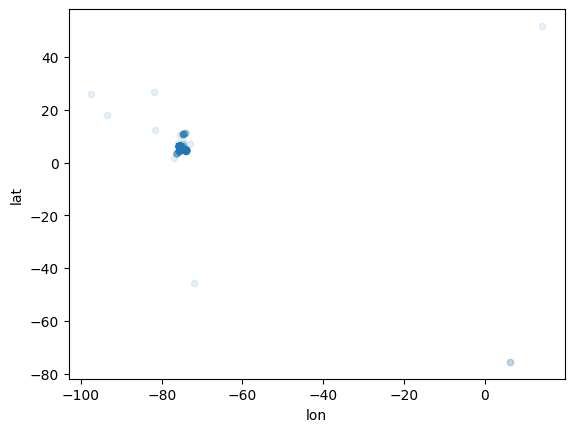

In [30]:
df_medellin_clean.plot(kind="scatter", x="lon", y="lat", alpha=0.1)

/var/folders/9r/f24wcwsd5lq1y7gwp439s8tm0000gn/T/ipykernel_84927/1320516810.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


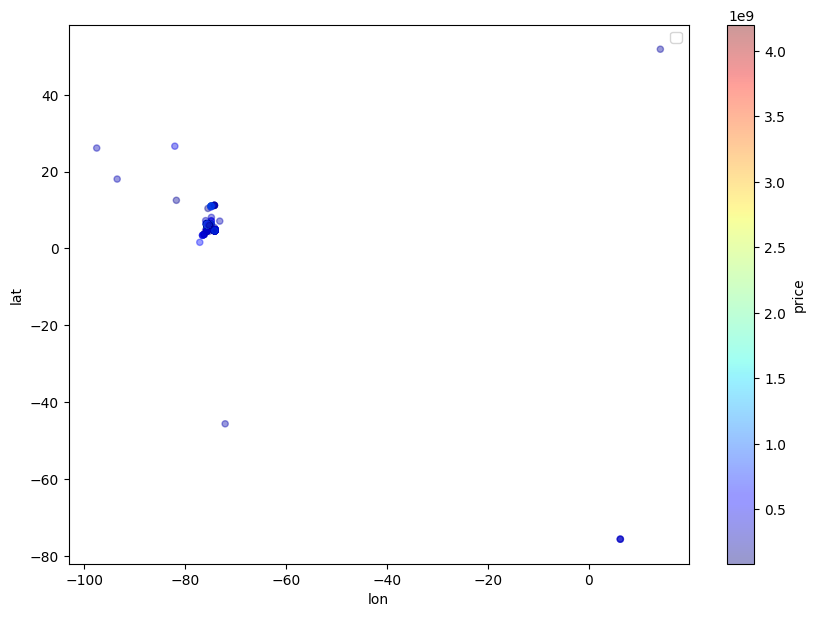

In [31]:
df_medellin_clean.plot(
    kind="scatter",
    x="lon",
    y="lat",
    alpha=0.4,
    figsize=(10, 7),
    c="price",
    cmap=plt.get_cmap("jet"),
    colorbar=True,
)
plt.legend()

## Buscando correlaciones

In [32]:
corr_matrix = df_medellin_clean.corr(numeric_only=True)
corr_matrix["price"].sort_values(ascending=False)

price              1.000000
bathrooms          0.674766
rooms              0.353544
bedrooms           0.259638
surface_total      0.111768
surface_covered    0.076278
lon                0.001399
lat               -0.008004
Name: price, dtype: float64

Vemos que las variables más correlacionadas son número de baños y area total:

array([[<Axes: xlabel='price', ylabel='price'>,
        <Axes: xlabel='bathrooms', ylabel='price'>,
        <Axes: xlabel='surface_total', ylabel='price'>,
        <Axes: xlabel='rooms', ylabel='price'>],
       [<Axes: xlabel='price', ylabel='bathrooms'>,
        <Axes: xlabel='bathrooms', ylabel='bathrooms'>,
        <Axes: xlabel='surface_total', ylabel='bathrooms'>,
        <Axes: xlabel='rooms', ylabel='bathrooms'>],
       [<Axes: xlabel='price', ylabel='surface_total'>,
        <Axes: xlabel='bathrooms', ylabel='surface_total'>,
        <Axes: xlabel='surface_total', ylabel='surface_total'>,
        <Axes: xlabel='rooms', ylabel='surface_total'>],
       [<Axes: xlabel='price', ylabel='rooms'>,
        <Axes: xlabel='bathrooms', ylabel='rooms'>,
        <Axes: xlabel='surface_total', ylabel='rooms'>,
        <Axes: xlabel='rooms', ylabel='rooms'>]], dtype=object)

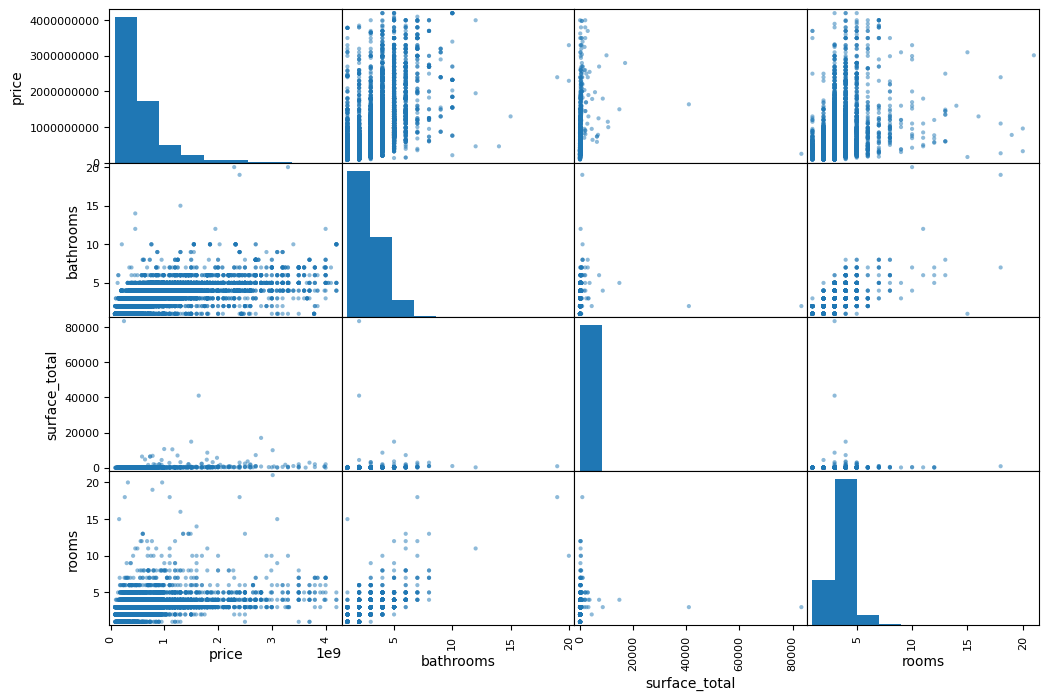

In [33]:
from pandas.plotting import scatter_matrix

attributes = [
    "price",
    "bathrooms",
    "surface_total",
    "rooms",
]
scatter_matrix(df_medellin_clean[attributes], figsize=(12, 8))

Veamos la gráfica de la variable más correlacionada por ahora:

<Axes: title={'center': 'Variable con mayor correlación'}, xlabel='bathrooms', ylabel='price'>

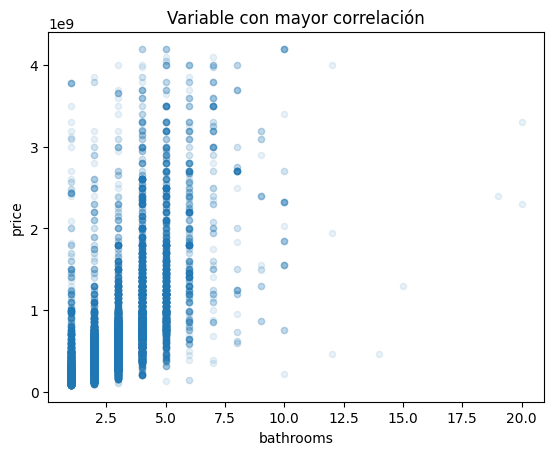

In [34]:
df_medellin_clean.plot(kind="scatter", x="bathrooms", y="price", alpha=0.1, title="Variable con mayor correlación")

Este análisis es para las variables númericas. Con las variables categoricas podemos hacer un histograma de frecuencias para ver que tanto se repite cada categoria

In [35]:
# Graficamos los 10 barrios más frecuentes para que sea legible
neighborhood_freq = df_medellin_clean["neighborhood"].fillna("Sin dato").value_counts().head(10).sort_values()
property_type_freq = df_medellin_clean["property_type"].fillna("Sin dato").value_counts()

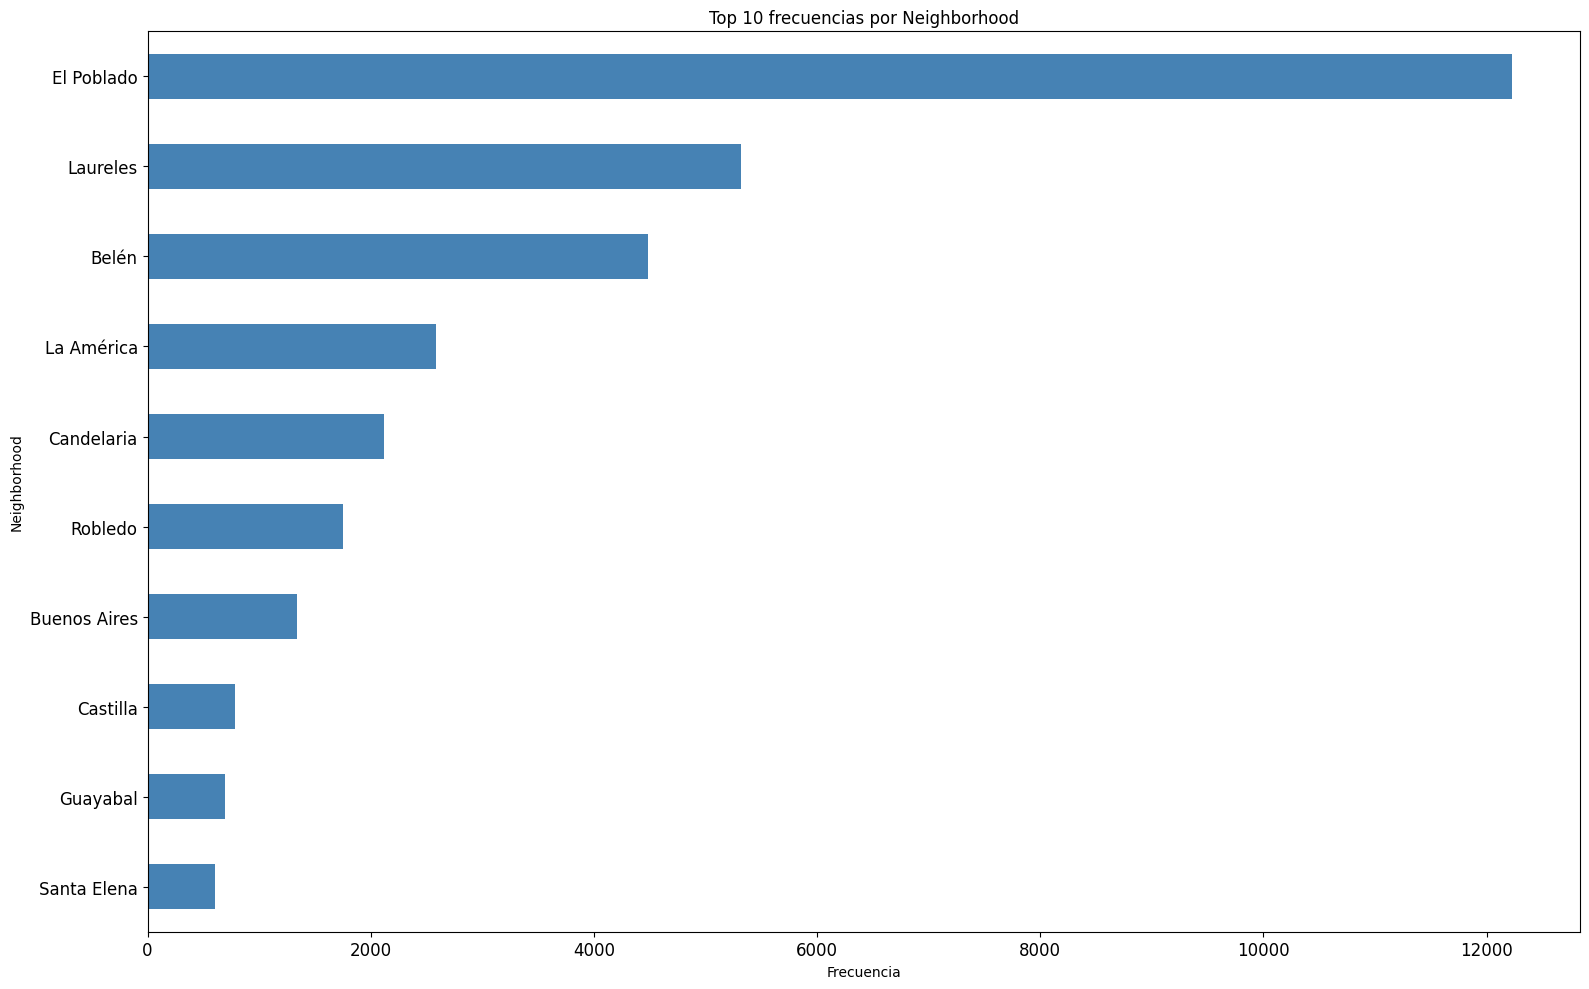

In [36]:
plt.figure(figsize=(16, 10))

neighborhood_freq.plot(
    kind="barh",
    color="steelblue",
    title="Top 10 frecuencias por Neighborhood",
)
plt.xlabel("Frecuencia")
plt.ylabel("Neighborhood")
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

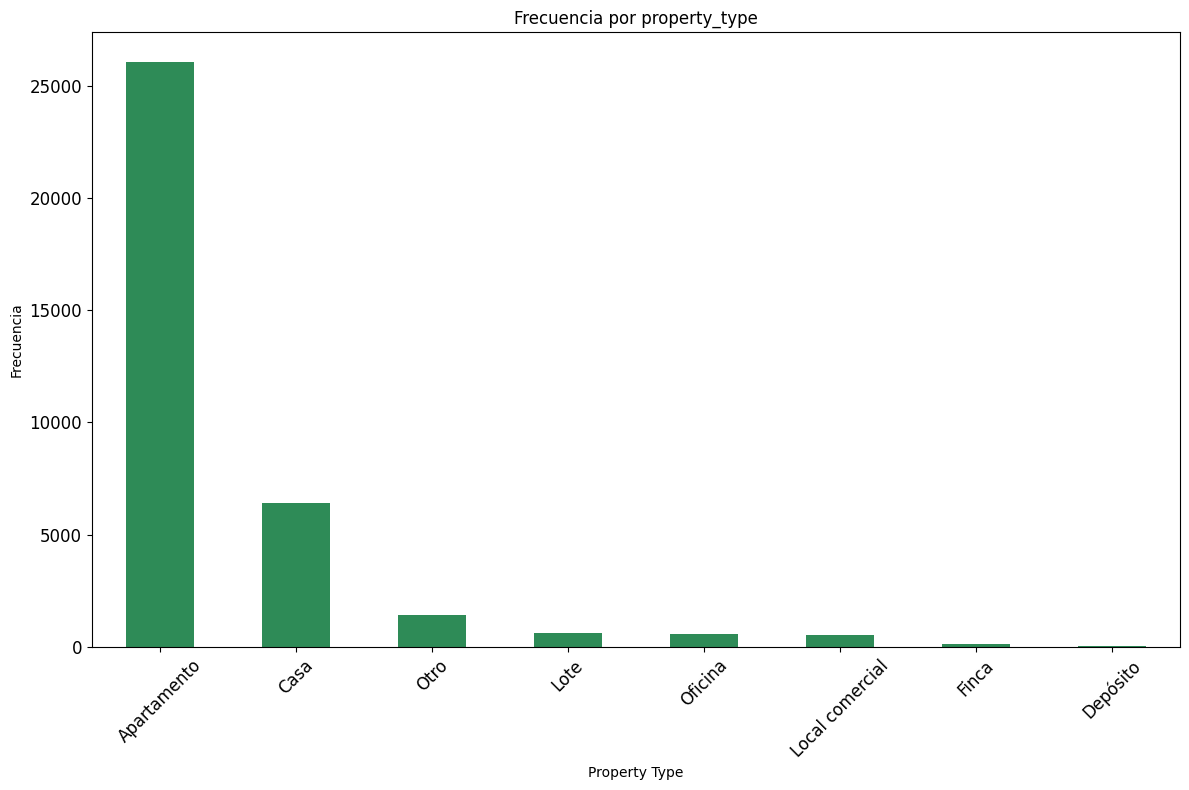

In [37]:
plt.figure(figsize=(12, 8))

property_type_freq.plot(
    kind="bar",
    color="seagreen",
    title="Frecuencia por property_type",
)
plt.xlabel("Property Type")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

# Entrenamiento

Separamos los datos que vamos a utilizar para el entrenamiento y los que vamos a usar para prueba. Una buena práctica es no manipular los datos de prueba hasta el final de nuestro proceso, cuando ya tengamos los modelos finales y vayamos a hacer la validación final, así que seguiremos esta recomendación.

In [38]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(df_medellin_clean, test_size=0.3, random_state=42)

In [39]:
train_set.head()

,lat,lon,neighborhood,rooms,bedrooms,bathrooms,surface_total,surface_covered,price,property_type
28776,6.212009,-75.559011,El Poblado,NaN,NaN,2.0,NaN,NaN,1.800000e+09,Oficina
4073,6.210000,-75.558000,El Poblado,NaN,3.0,4.0,NaN,NaN,7.100000e+08,Apartamento
10705,6.276607,-75.559693,Aranjuez,NaN,NaN,2.0,NaN,NaN,1.870000e+08,Casa
34244,6.282000,-75.561000,Aranjuez,2.0,2.0,1.0,65.0,65.0,1.400000e+08,Apartamento
6740,6.188863,-75.561118,El Poblado,4.0,4.0,NaN,NaN,NaN,8.900000e+08,Apartamento


Separamos los datos de la variable objetivo, en este caso precio

In [40]:
train_set.info()

<class 'pandas.DataFrame'>
Index: 25069 entries, 28776 to 16121
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   lat              25069 non-null  float64
 1   lon              25069 non-null  float64
 2   neighborhood     24649 non-null  str    
 3   rooms            8247 non-null   float64
 4   bedrooms         13371 non-null  float64
 5   bathrooms        17134 non-null  float64
 6   surface_total    897 non-null    float64
 7   surface_covered  948 non-null    float64
 8   price            25069 non-null  float64
 9   property_type    25069 non-null  str    
dtypes: float64(8), str(2)
memory usage: 2.1 MB


In [41]:
house_data = train_set.drop(columns=["price"])
target = train_set["price"]

Usamos SimpleImputer para llenar los valores NaN de las variables numéricas, además, creamos un pipeline que se puede reutilizar en el momento de la evaluación. Adicionalmente, hacemos estandarización en los datos para evitar problemas con outliers y tener los datos escalados para el modelo. Esto para las variables numéricas:

In [42]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer


house_num_features = house_data.drop(["neighborhood", "property_type"], axis=1)

num_pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("std_scaler", StandardScaler()),
    ]
)

Ahora procesamos las variables categóricas, en este caso tenemos property_type y neighborhood. Para ambas haremos OneHotEncoder ya que no son muchas las categorías disponibles

In [43]:
house_data["neighborhood"] = house_data["neighborhood"].fillna("Unknown")

In [44]:
house_data

,lat,lon,neighborhood,rooms,bedrooms,bathrooms,surface_total,surface_covered,property_type
28776,6.212009,-75.559011,El Poblado,NaN,NaN,2.0,NaN,NaN,Oficina
4073,6.210000,-75.558000,El Poblado,NaN,3.0,4.0,NaN,NaN,Apartamento
10705,6.276607,-75.559693,Aranjuez,NaN,NaN,2.0,NaN,NaN,Casa
34244,6.282000,-75.561000,Aranjuez,2.0,2.0,1.0,65.0,65.0,Apartamento
6740,6.188863,-75.561118,El Poblado,4.0,4.0,NaN,NaN,NaN,Apartamento
...,...,...,...,...,...,...,...,...,...
17195,6.183168,-75.568113,El Poblado,NaN,NaN,6.0,NaN,NaN,Casa
6378,6.215963,-75.606627,Altavista,3.0,3.0,NaN,NaN,NaN,Apartamento
11499,6.225233,-75.565447,Candelaria,3.0,3.0,NaN,NaN,NaN,Apartamento
895,6.237220,-75.588056,Belén,4.0,4.0,NaN,NaN,NaN,Apartamento


In [45]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

num_attribs = list(house_num_features)
cat_attribs = ["neighborhood", "property_type"]

full_pipeline = ColumnTransformer(
    [
        ("num", num_pipeline, num_attribs),
        ("cat", OneHotEncoder(), cat_attribs),
    ]
)
housing_prepared = full_pipeline.fit_transform(house_data)

Una vez preparado el dataset de entrenamiento, podemos proceder a evaluar los modelos.

## Random Forest


In [46]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Training
forest_reg = RandomForestRegressor()
forest_reg.fit(housing_prepared, target)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

### Resultados

In [47]:
predicted_price = forest_reg.predict(housing_prepared)

random_forest_mbe = mean_absolute_error(target, predicted_price)
random_forest_mse = mean_squared_error(target, predicted_price)
random_forest_rmse = np.sqrt(random_forest_mse)
random_forest_r2s = r2_score(target, predicted_price)

print("MAE:", random_forest_mbe)
print("MSE:", random_forest_mse)
print("RMSE:", random_forest_rmse)
print("R2_score:", random_forest_r2s)

MAE: 68269240.20988034
MSE: 2.034690224824398e+16
RMSE: 142642568.14935708
R2_score: 0.9345068365024316


**Usando cross-validation**

In [48]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    forest_reg,
    housing_prepared,
    target,
    scoring="neg_mean_squared_error",
    cv=10,
)
random_forest_rmse_scores = np.sqrt(-scores)

In [49]:
def display_scores(scores):
    print("Puntajes:", scores)
    print("Media:", scores.mean())
    print("Desviación estándar:", scores.std())

display_scores(random_forest_rmse_scores)

Puntajes: [3.22971302e+08 2.95924067e+08 3.12229354e+08 3.02828786e+08
 3.04323145e+08 2.81613711e+08 3.11232507e+08 3.01727058e+08
 3.13061695e+08 2.80942422e+08]
Media: 302685404.6520357
Desviación estándar: 12843034.748387784


Vemos un error típico de 306M con una variación aproximada de 18M. Tendremos que optimizar los parámetros para intentar mejorar el modelo.

## XGBoost

In [50]:
from xgboost import XGBRegressor

r_xgboost = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
r_xgboost.fit(housing_prepared, target)
r_xgboost.n_estimators

100

### Resultados

In [51]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

predicted_price = r_xgboost.predict(housing_prepared)

xgboost_mbe = mean_absolute_error(target, predicted_price)
xgboost_mse = mean_squared_error(target, predicted_price)
xgboost_rmse = np.sqrt(xgboost_mse)
xgboost_r2s = r2_score(target, predicted_price)

print("MAE:", xgboost_mbe)
print("MSE:", xgboost_mse)
print("RMSE:", xgboost_rmse)
print("R2_score:", xgboost_r2s)

MAE: 205620989.57832384
MSE: 1.276192861334072e+17
RMSE: 357238416.3740053
R2_score: 0.5892155636173293


## Optimizando los hiperparametros

A continuación se optimizan los hiperparámetros de Random Forest y XGBoost mediante GridSearchCV, que evalúa diferentes combinaciones y conserva la de mejor desempeño.

## Optimizando para Random Forest

In [52]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

param_grid = [
    {
        'n_estimators': [50, 100],
        'max_depth': [None, 10],
        'max_features': ['sqrt', 0.5]
    }
]

random_forest_reg_op = RandomForestRegressor(random_state=42, n_jobs=-1)

grid_search_random_forest = GridSearchCV(random_forest_reg_op, param_grid, cv=3,
                                         scoring='neg_mean_squared_error',
                                         return_train_score=True,
                                         n_jobs=-1)

grid_search_random_forest.fit(housing_prepared, target)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'max_depth': [None, 10], 'max_features': ['sqrt', 0.5], 'n_estimators': [50, 100]}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is disp

In [53]:
grid_search_random_forest.best_params_

{'max_depth': None, 'max_features': 0.5, 'n_estimators': 100}

In [54]:
best_params_random_forest = pd.DataFrame(
    grid_search_random_forest.best_params_.items(),
    columns=["Hiperparámetro", "Mejor valor"]
)

best_params_random_forest

,Hiperparámetro,Mejor valor
0,max_depth,NaN
1,max_features,0.5
2,n_estimators,100.0


Usando el mejor modelo encontrado:

In [55]:
best_random_forest = grid_search_random_forest.best_estimator_
best_random_forest
y_pred_best_random_forest = best_random_forest.predict(housing_prepared)

### Resultados

In [56]:
best_random_forest_mbe = mean_absolute_error(target, y_pred_best_random_forest)
best_random_forest_mse = mean_squared_error(target, y_pred_best_random_forest)
best_random_forest_rmse = np.sqrt(best_random_forest_mse)
best_random_forest_r2s = r2_score(target, y_pred_best_random_forest)

print("MAE:", best_random_forest_mbe)
print("MSE:", best_random_forest_mse)
print("RMSE:", best_random_forest_rmse)
print("R2_score:", best_random_forest_r2s)

MAE: 68044745.04686733
MSE: 2.0326646494301932e+16
RMSE: 142571548.68451816
R2_score: 0.9345720362752771


## Optimización XGBoost

In [57]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

param_grid = [
    {
        'n_estimators': [50, 100, 200],
        'max_depth': [2, 3, 4],
        'learning_rate': [0.03, 0.05, 0.1],
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0]
    }
]

xgboost_reg_op = XGBRegressor(random_state=42, objective='reg:squarederror', n_jobs=-1)

grid_search_xgboost = GridSearchCV(xgboost_reg_op, param_grid, cv=3,
                                   scoring='neg_mean_squared_error',
                                   return_train_score=True,
                                   n_jobs=-1)

grid_search_xgboost.fit(housing_prepared, target)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.03, 0.05, ...], 'max_depth': [2, 3, ...], 'n_estimators': [50, 100, ...], ...}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation 

In [58]:
grid_search_xgboost.best_params_

{'colsample_bytree': 1.0,
 'learning_rate': 0.1,
 'max_depth': 4,
 'n_estimators': 200,
 'subsample': 0.8}

Usando el mejor modelo encontrado:

In [59]:
best_xgboost = grid_search_xgboost.best_estimator_
best_xgboost
y_pred_best_xgboost = best_xgboost.predict(housing_prepared)

### Resultados

In [60]:
best_xgboost_mbe = mean_absolute_error(target, y_pred_best_xgboost)
best_xgboost_mse = mean_squared_error(target, y_pred_best_xgboost)
best_xgboost_rmse = np.sqrt(best_xgboost_mse)
best_xgboost_r2s = r2_score(target, y_pred_best_xgboost)

print("MAE:", best_xgboost_mbe)
print("MSE:", best_xgboost_mse)
print("RMSE:", best_xgboost_rmse)
print("R2_score:", best_xgboost_r2s)

MAE: 183441318.9790179
MSE: 1.0040852299349834e+17
RMSE: 316873039.23416764
R2_score: 0.6768023096228282


# Evaluación

Hasta ahora hemos entrenado y probado diferentes modelos en el data set de entrenamiento. Optimizamos los parámetros de los modelos usando Grid Search y tenemos ahora las mejores versiones de cada modelo. Vamos ahora a hacer la evaluación final usando el data set de test y comparar los resultados, tanto de los modelos base como de los optimizados

In [61]:
test_data = test_set.drop(columns=["price"])
test_data["neighborhood"] = test_data["neighborhood"].fillna("Unknown")
test_target = test_set["price"]

test_prepared = full_pipeline.transform(test_data)

In [62]:
test_data.info()

<class 'pandas.DataFrame'>
Index: 10745 entries, 32240 to 35826
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   lat              10745 non-null  float64
 1   lon              10745 non-null  float64
 2   neighborhood     10745 non-null  str    
 3   rooms            3453 non-null   float64
 4   bedrooms         5635 non-null   float64
 5   bathrooms        7434 non-null   float64
 6   surface_total    378 non-null    float64
 7   surface_covered  410 non-null    float64
 8   property_type    10745 non-null  str    
dtypes: float64(7), str(2)
memory usage: 839.5 KB


In [63]:
test_target.info()

<class 'pandas.Series'>
Index: 10745 entries, 32240 to 35826
Series name: price
Non-Null Count  Dtype  
--------------  -----  
10745 non-null  float64
dtypes: float64(1)
memory usage: 167.9 KB


In [64]:
test_target[test_target.isna()]

Series([], Name: price, dtype: float64)

## Modelos base

### Random Forest base

In [65]:
y_pred_test_random_forest = forest_reg.predict(test_prepared)

test_random_forest_mbe = mean_absolute_error(test_target, y_pred_test_random_forest)
test_random_forest_mse = mean_squared_error(test_target, y_pred_test_random_forest)
test_random_forest_rmse = np.sqrt(test_random_forest_mse)
test_random_forest_r2s = r2_score(test_target, y_pred_test_random_forest)

print("MAE:", test_random_forest_mbe)
print("MSE:", test_random_forest_mse)
print("RMSE:", test_random_forest_rmse)
print("R2_score:", test_random_forest_r2s)

MAE: 144146127.4293515
MSE: 8.894278003107224e+16
RMSE: 298232761.4985856
R2_score: 0.7063227742671383


### XGBoost base

In [66]:
y_pred_test_xgboost = r_xgboost.predict(test_prepared)

test_xgboost_mbe = mean_absolute_error(test_target, y_pred_test_xgboost)
test_xgboost_mse = mean_squared_error(test_target, y_pred_test_xgboost)
test_xgboost_rmse = np.sqrt(test_xgboost_mse)
test_xgboost_r2s = r2_score(test_target, y_pred_test_xgboost)

print("MAE:", test_xgboost_mbe)
print("MSE:", test_xgboost_mse)
print("RMSE:", test_xgboost_rmse)
print("R2_score:", test_xgboost_r2s)

MAE: 212393905.96798512
MSE: 1.3744835109577216e+17
RMSE: 370740274.4452943
R2_score: 0.5461638323283688


## Modelos optimizados

### Random Forest optimizado

In [67]:
y_pred_test_best_random_forest = best_random_forest.predict(test_prepared)

test_best_random_forest_mbe = mean_absolute_error(test_target, y_pred_test_best_random_forest)
test_best_random_forest_mse = mean_squared_error(test_target, y_pred_test_best_random_forest)
test_best_random_forest_rmse = np.sqrt(test_best_random_forest_mse)
test_best_random_forest_r2s = r2_score(test_target, y_pred_test_best_random_forest)

print("MAE:", test_best_random_forest_mbe)
print("MSE:", test_best_random_forest_mse)
print("RMSE:", test_best_random_forest_rmse)
print("R2_score:", test_best_random_forest_r2s)

MAE: 143161927.8771472
MSE: 8.656130737223323e+16
RMSE: 294213030.5955758
R2_score: 0.7141860801292012


### XGBoost optimizado

In [68]:
y_pred_test_best_xgboost = best_xgboost.predict(test_prepared)

test_best_xgboost_mbe = mean_absolute_error(test_target, y_pred_test_best_xgboost)
test_best_xgboost_mse = mean_squared_error(test_target, y_pred_test_best_xgboost)
test_best_xgboost_rmse = np.sqrt(test_best_xgboost_mse)
test_best_xgboost_r2s = r2_score(test_target, y_pred_test_best_xgboost)

print("MAE:", test_best_xgboost_mbe)
print("MSE:", test_best_xgboost_mse)
print("RMSE:", test_best_xgboost_rmse)
print("R2_score:", test_best_xgboost_r2s)

MAE: 198111760.7493718
MSE: 1.2169538596600944e+17
RMSE: 348848657.68124926
R2_score: 0.5981780272383888


## Resultados

A continuación vamos a analizar los resultados de nuestros modelos. Algo que podemos analizar es la importancia que tiene cada característica para el modelo, usando el modelo optimizado de Random Forest para esto:

Top 10 características más importantes:
                  Feature  Importance
                bathrooms    0.256779
                      lat    0.212653
                      lon    0.209741
  neighborhood_El Poblado    0.078342
property_type_Apartamento    0.038842
                 bedrooms    0.035752
                    rooms    0.028581
       property_type_Casa    0.023746
 neighborhood_Santa Elena    0.021697
       property_type_Otro    0.013290


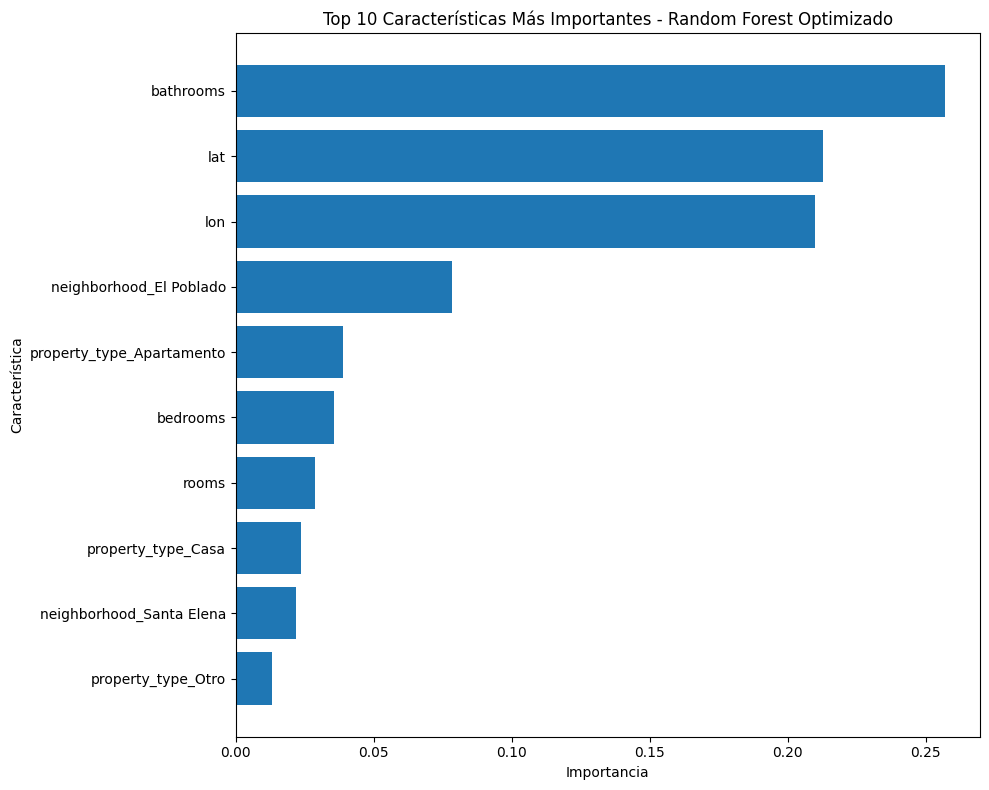


Importancia total de variables numéricas: 0.7667
Importancia total de variables categóricas: 0.2333


In [69]:
num_attribs = ['lat', 'lon', 'rooms', 'bedrooms', 'bathrooms', 'surface_total', 'surface_covered']


cat_encoder = full_pipeline.named_transformers_['cat']
cat_feature_names = []
for i, cat in enumerate(['neighborhood', 'property_type']):
    categories = cat_encoder.categories_[i]
    cat_feature_names.extend([f"{cat}_{category}" for category in categories])

all_feature_names = num_attribs + cat_feature_names

feature_importances = best_random_forest.feature_importances_


importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': feature_importances
}).sort_values('Importance', ascending=False)

print("Top 10 características más importantes:")
print(importance_df.head(10).to_string(index=False))


plt.figure(figsize=(10, 8))
top_features = importance_df.head(10)
plt.barh(range(len(top_features)), top_features['Importance'])
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Importancia')
plt.ylabel('Característica')
plt.title('Top 10 Características Más Importantes - Random Forest Optimizado')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

num_importance = importance_df[importance_df['Feature'].isin(num_attribs)]['Importance'].sum()
cat_importance = importance_df[~importance_df['Feature'].isin(num_attribs)]['Importance'].sum()

print(f"\nImportancia total de variables numéricas: {num_importance:.4f}")
print(f"Importancia total de variables categóricas: {cat_importance:.4f}")


Del resultado anterior, podemos confirmar que el número de baños es la caracteristica más importante y relacionada con el precio. Adicionalmente, vemos que la ubicación también es importante. Esto era algo que no mostraba la correlación. Incluso vemos que el hecho de que un inmueble esté ubicado en el poblado tiene una gran importancia en relación al precio.

Ahora vamos a comparar los resultados de todos modelos:

In [70]:
test_model_comparison_values = pd.DataFrame(
    {
        "Random Forest base": [test_random_forest_mbe, test_random_forest_mse, test_random_forest_rmse, test_random_forest_r2s],
        "Random Forest optimizado": [test_best_random_forest_mbe, test_best_random_forest_mse, test_best_random_forest_rmse, test_best_random_forest_r2s],
        "XGBoost base": [test_xgboost_mbe, test_xgboost_mse, test_xgboost_rmse, test_xgboost_r2s],
        "XGBoost optimizado": [test_best_xgboost_mbe, test_best_xgboost_mse, test_best_xgboost_rmse, test_best_xgboost_r2s],
    },
    index=["MAE", "MSE", "RMSE", "R2_score"],
)

metric_formatters = {
    "MAE": lambda value: f"{value:.3f}",
    "MSE": lambda value: f"{value:.3e}",
    "RMSE": lambda value: f"{value:.3f}",
    "R2_score": lambda value: f"{value:.3f}",
}

test_model_comparison = pd.DataFrame(
    {
        model_name: [
            metric_formatters[metric](test_model_comparison_values.loc[metric, model_name])
            for metric in test_model_comparison_values.index
        ]
        for model_name in test_model_comparison_values.columns
    }
)

test_model_comparison.insert(0, "Métrica", test_model_comparison_values.index)

test_model_comparison

,Métrica,Random Forest base,Random Forest optimizado,XGBoost base,XGBoost optimizado
0,MAE,144146127.429,143161927.877,212393905.968,198111760.749
1,MSE,8.894e+16,8.656e+16,1.374e+17,1.217e+17
2,RMSE,298232761.499,294213030.596,370740274.445,348848657.681
3,R2_score,0.706,0.714,0.546,0.598


# Conclusiones

Vemos que los resultados de la evaluación con el dataset de prueba variaron mucho comparados con los de la fase de entrenamiento. Generalmente se recomienda usar el dataset de test hasta la parte final de nuestro proceso, para evitar feature leakage y sesgarnos. Vemos que la mayoría de los modelos tuvieron un rendimiento menor con el dataset de prueba. Sin embargo, algunos tuvieron un rendimiento aceptable, considerando que se está usando un dataset real. Normalmente con datasets académicos los resultados son mejores porque son datos curados y seleccionados específicamente para mostrar cómo se usan los modelos.

Así mismo, vemos que la optimización también tuvo un leve efecto en el mejoramiento de los modelos, aunque no muy destacable, por lo general de décimas o centésimas. Lo cual nos da a entender que no había mucho espacio para mejorar. Algunas opciones que se pueden tratar serían mejorar el tratamiento de los outliers o ampliarlo a rangos más amplios, probar mayor cantidad de parámetros o modelos más avanzados.

Adicionalmente se observa que el mejor modelo fue el Random Forest Optimizado, con un R2 de 0.71 y un error típico de cerca de 300M. Considerando que había varios inmuebles con valores de miles de millones de pesos, podría ser un error aceptable. Podemos ver cómo se comparan las predicciones con el valor real del data set de test en la siguiente gráfica, para el modelo Random Forest Optimizado:

Text(0.5, 1.0, 'Predicciones vs Valores Reales - Random Forest Optimizado')

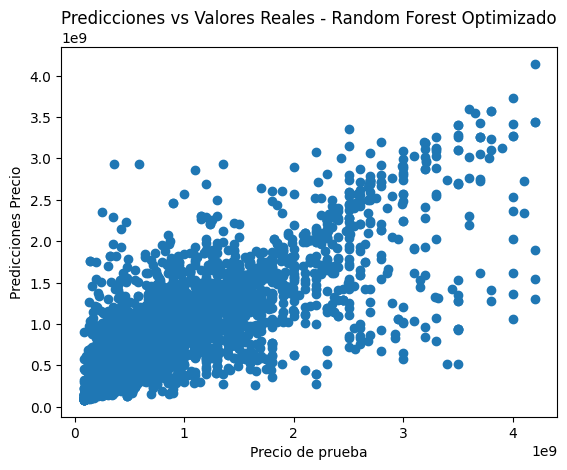

In [71]:
import matplotlib.pyplot as plt
plt.scatter(test_target, y_pred_test_best_random_forest)
plt.xlabel("Precio de prueba")
plt.ylabel("Predicciones Precio")
plt.title("Predicciones vs Valores Reales - Random Forest Optimizado")

Vemos que casi se logra una línea diagonal, lo cual indica que el modelo logra capturar una parte importante del comportamiento del precio. Esto explica el resultado de 0.71 para la métrica R2 score. Sin embargo, también se observa que la dispersión aumenta para los valores más altos del precio, por lo que el modelo tiene más dificultad para predecir inmuebles costosos con la misma precisión que en los inmuebles con precios medios y bajos.

Por último, mencionar que parte importante de este proyecto fue encontrar un buen dataset y hacer el correcto procesamiento de datos. A pesar de que el dataset que se encontró tenía una enorme cantidad de datos, muchos de estos se filtraron, inicialmente para trabajar solo los datos de Medellín, pero adicionalmente, se tuvieron que omitir muchos registros porque estaban incompletos, ya sea que le faltaran una o varias características importantes. Se le dio prioridad a la ubicación, y todos los registros que se usaron tenían esta característica, ya que un trabajo futuro de este proyecto será aplicarlo con modelos espaciales. Aún así, quedaron varios registros que le faltaban valores para las características como número de habitaciones o área total; características muy importantes para definir el precio de un inmueble. Se usó imputación para estos casos y se escalaron los datos; sin embargo, esta falencia de los datos podría explicar gran parte de los errores.

Según las correlaciones encontradas, algo curioso es que el número de baños tiene el mayor peso. Esto podría tener sentido ya que inmuebles más grandes tienden a tener más baños, pero se esperaba que el área total tuviera más peso. Esto puede deberse a que precisamente el área total era una de las características que más faltaban en los registros. Así mismo, analizando la importancia de las características dadas por Random Forest, vemos que la ubicación tiene una importancia relevante.

Un trabajo interesante a futuro sería construir un dataset más completo, explorando fuentes de datos como el observatorio inmobiliario de Medellín, que, aunque se tuvo en cuenta para el proyecto, se descartó porque no incluía variables como número de habitaciones. Otra opción sería construir un mejor dataset usando web scraping de los principales portales inmobiliarios. Esto sería con fines académicos. Con este dataset se podrían probar nuevamente los modelos usados y ver si se tienen mejores resultados. Otra opción sería compararlos con modelos espaciales que le den un mayor peso a la ubicación de los inmuebles.